# Clustering

**Design choices**
- `came_back` / `is_dropout_point` are used only for post-hoc interpretation, never as clustering features.
- Demographic and school columns are separated from behavioral columns so we can compare all-feature and behavior-only clustering.
- Calendar variables are excluded from trajectory clustering by default to avoid clustering users mostly by seasonality.


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

from dataclasses import dataclass
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from sklearn.cluster import AgglomerativeClustering, KMeans
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import silhouette_score
    from sklearn.mixture import GaussianMixture
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook requires scikit-learn. Use the same environment as the original clustering notebook, "
        "or install the project dependencies before running it."
    ) from exc

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")


## 1. Configuration

To put in a .py later maybe.


Flip `RUN_STAGE2 = False` to `True` when  rebuild the weekly trajectory dataset from the raw Lernnavi logs.


In [31]:
@dataclass(frozen=True)
class Config:
    project_dir: Path = Path.cwd()
    data_dir: Path = Path("data")
    output_dir: Path = Path("outputs")
    stage1_file: Path = Path("data/stage1.csv.gz")
    random_state: int = RANDOM_STATE
    k_min: int = 2
    k_max: int = 8
    silhouette_sample_size: int = 5000
    main_behavior_k: int = 2
    exploratory_behavior_k: int = 5
    run_stage2: bool = True
    stage2_sequence_length: int = 12
    stage2_k: int = 5
    agglo_sample_size: int = 5000
    save_outputs: bool = True

CFG = Config()
CFG.output_dir.mkdir(exist_ok=True)
CFG


Config(project_dir=WindowsPath('c:/Users/loicm/Documents/EPFL/2025-2026/MA4/ML_for_BD/CS-421-Project-learnavi'), data_dir=WindowsPath('data'), output_dir=WindowsPath('outputs'), stage1_file=WindowsPath('data/stage1.csv.gz'), random_state=42, k_min=2, k_max=8, silhouette_sample_size=5000, main_behavior_k=2, exploratory_behavior_k=5, run_stage2=True, stage2_sequence_length=12, stage2_k=5, agglo_sample_size=5000, save_outputs=True)

## 2. Utility Functions

To put in a .py later maybe


In [3]:
def load_stage1(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing Stage 1 file: {path}")
    df = pd.read_csv(path)
    required = {"user_id", "came_back"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Stage 1 dataset is missing required columns: {sorted(missing)}")
    return df


def demographic_columns(df: pd.DataFrame) -> list[str]:
    prefixes = ("gender_", "canton_", "school_")
    explicit = {"study", "class_year"}
    return [c for c in df.columns if c.startswith(prefixes) or c in explicit]


def numeric_feature_columns(df: pd.DataFrame, exclude: set[str]) -> list[str]:
    candidates = df.drop(columns=list(exclude & set(df.columns)), errors="ignore")
    return candidates.select_dtypes(include=["number", "bool"]).columns.tolist()


def preprocessing_pipeline() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])


def preprocess_features(df: pd.DataFrame, feature_cols: list[str]) -> tuple[np.ndarray, Pipeline]:
    pipe = preprocessing_pipeline()
    X = pipe.fit_transform(df[feature_cols])
    return X, pipe


def evaluate_kmeans(X: np.ndarray, k_values: range, *, sample_size: int, random_state: int) -> pd.DataFrame:
    rows = []
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = model.fit_predict(X)
        score = silhouette_score(
            X,
            labels,
            sample_size=min(sample_size, X.shape[0]),
            random_state=random_state,
        )
        rows.append({"k": k, "silhouette": score, "inertia": model.inertia_})
    return pd.DataFrame(rows)


def fit_kmeans(X: np.ndarray, k: int, *, random_state: int) -> KMeans:
    model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    model.fit(X)
    return model


def cluster_overview(df: pd.DataFrame, cluster_col: str, label_col: str = "came_back") -> pd.DataFrame:
    overview = (
        df.groupby(cluster_col)
        .agg(
            n_users=("user_id", "count"),
            continuation_rate=(label_col, "mean"),
        )
        .reset_index()
        .sort_values(cluster_col)
    )
    overview["dropout_rate"] = 1 - overview["continuation_rate"]
    overview["share_users"] = overview["n_users"] / overview["n_users"].sum()
    return overview


def top_z_features(df: pd.DataFrame, cluster_col: str, feature_cols: list[str], top_n: int = 8) -> pd.DataFrame:
    global_mean = df[feature_cols].mean()
    global_std = df[feature_cols].std().replace(0, np.nan)
    cluster_means = df.groupby(cluster_col)[feature_cols].mean()
    z = (cluster_means - global_mean) / global_std

    rows = []
    for cluster_id in z.index:
        strongest = z.loc[cluster_id].dropna().abs().sort_values(ascending=False).head(top_n).index
        for feature in strongest:
            rows.append({
                "cluster": cluster_id,
                "feature": feature,
                "z_difference": z.loc[cluster_id, feature],
                "cluster_mean": cluster_means.loc[cluster_id, feature],
                "global_mean": global_mean.loc[feature],
            })
    return pd.DataFrame(rows)


def plot_k_diagnostics(scores: pd.DataFrame, title: str) -> None:
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(scores["k"], scores["silhouette"], marker="o", color="#2563eb", label="Silhouette")
    ax1.set_xlabel("Number of clusters k")
    ax1.set_ylabel("Silhouette score")
    ax1.set_title(title)
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    ax2.plot(scores["k"], scores["inertia"], marker="s", color="#dc2626", alpha=0.65, label="Inertia")
    ax2.set_ylabel("K-Means inertia")
    fig.tight_layout()
    plt.show()


## 3. Load Stage 1 Data

Stage 1 contains user-level features aggregated over the first activity window. The target `came_back` is kept for interpretation only.


In [4]:
df_stage1 = load_stage1(CFG.stage1_file).copy()
print("Stage 1 shape:", df_stage1.shape)
print("Continuation rate:", df_stage1["came_back"].mean().round(3))
df_stage1.head()


Stage 1 shape: (22466, 90)
Continuation rate: 0.608


,user_id,total_events_0_2,n_active_days_0_2,n_click_events_0_2,n_view_events_0_2,n_sessions_0_2,n_topics_event_0_2,mean_hour_0_2,std_hour_0_2,total_transactions_0_2,correct_rate_0_2,partial_rate_0_2,mean_evaluation_score_0_2,avg_response_time_0_2,n_documents_0_2,n_topics_transaction_0_2,std_evaluation_score_0_2,std_response_time_0_2,session_duration_mean_0_2,session_duration_std_0_2,time_between_sessions_mean_0_2,retry_ratio_0_2,review_rate_0_2,study,class_year,gender_FEMALE,gender_MALE,gender_Other,gender_Unknown,canton_AG,canton_AI,canton_AR,canton_Andere,canton_BE,canton_BL,canton_BS,canton_FL,canton_FR,canton_GL,canton_GR,canton_JU,canton_LU,canton_NE,canton_SG,canton_SH,canton_SO,canton_SZ,canton_TG,canton_UR,canton_Unknown,canton_VD,canton_VS,canton_ZG,canton_ZH,school_2. Klasse LG,school_3. Klasse LG,school_4. Klasse LG,school_5. Klasse LG,school_6. Klasse LG,school_7. Klasse LG,school_BME,school_BME (Matura),school_FM,school_FM (Fachmaturität),school_FMS,school_Fachmaturität Pädagogik,school_Gymnasium,school_HMS,school_IMS,school_ISME,school_ISME (Matura),school_K+S,school_KME Passerelle,school_KME Teilzeit,school_KME Vollzeit,school_Keine Angabe,school_Kurzzeitgymnasium,school_Langzeitgymnasium,school_Liceo Artistico,school_Maturität für Erwachsene,school_Passerelle,school_Passerelle BM/FM,school_Sekundarschule P,school_UG,school_Unknown,school_Vorkurs PH für Berufsleute,school_Vorkurs Pädagogik,school_WMS,school_andere,came_back
0,387604,2.0,2.0,0.0,2.0,0.0,0.0,9.000000,5.656854,2,0.000000,0.000000,0.000000,0.000000,1,0,0.000000,0.000000,0.0000,0.000000,0.000,2.000000,0.000000,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
1,387605,12.0,1.0,7.0,5.0,2.0,2.0,6.000000,0.000000,5,0.400000,0.200000,0.500000,39.957000,5,2,0.500000,8.813259,67.9890,91.349711,11.093,1.000000,0.000000,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,387608,101.0,2.0,35.0,66.0,2.0,1.0,8.603960,1.225391,34,0.382353,0.058824,0.411765,26.930133,15,1,0.484152,17.598100,268.7685,140.867692,213.765,2.266667,1.000000,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
3,387613,11.0,1.0,3.0,8.0,1.0,1.0,12.000000,0.000000,2,0.500000,0.000000,0.500000,24.976000,2,1,0.707107,0.000000,40.1110,0.000000,0.000,1.000000,2.000000,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
4,387615,348.0,6.0,76.0,272.0,2.0,1.0,9.784483,2.961246,37,0.270270,0.081081,0.310811,46.730929,19,1,0.446458,47.616260,428.2360,176.792252,14.439,1.947368,1.428571,0,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [5]:
ID_COL = "user_id"
LABEL_COL = "came_back"

DEMO_COLS = demographic_columns(df_stage1)
EXCLUDE_BASE = {ID_COL, LABEL_COL}

all_numeric_features = numeric_feature_columns(df_stage1, exclude=EXCLUDE_BASE)
behavior_features = [c for c in all_numeric_features if c not in DEMO_COLS]

print(f"All numeric features: {len(all_numeric_features)}")
print(f"Demographic/school features: {len(DEMO_COLS)}")
print(f"Behavior-only features: {len(behavior_features)}")
behavior_features[:10]


All numeric features: 88
Demographic/school features: 66
Behavior-only features: 22


['total_events_0_2',
 'n_active_days_0_2',
 'n_click_events_0_2',
 'n_view_events_0_2',
 'n_sessions_0_2',
 'n_topics_event_0_2',
 'mean_hour_0_2',
 'std_hour_0_2',
 'total_transactions_0_2',
 'correct_rate_0_2']

## 4. All-Feature Baseline

This baseline reproduces the broad clustering setup, including behavioral plus demographic/school encoded variables. It is useful as a diagnostic, but the behavior-only model is usually easier to interpret for learner profiles.


In [6]:
X_all, all_preprocess = preprocess_features(df_stage1, all_numeric_features)
all_scores = evaluate_kmeans(
    X_all,
    range(CFG.k_min, CFG.k_max + 1),
    sample_size=CFG.silhouette_sample_size,
    random_state=CFG.random_state,
)
all_scores


,k,silhouette,inertia
0,2,0.225944,1.834513e+06
1,3,0.125124,1.760117e+06
2,4,0.074839,1.709463e+06
3,5,0.071979,1.676671e+06
4,6,0.076096,1.654227e+06
5,7,0.084669,1.622143e+06
6,8,0.082287,1.592068e+06


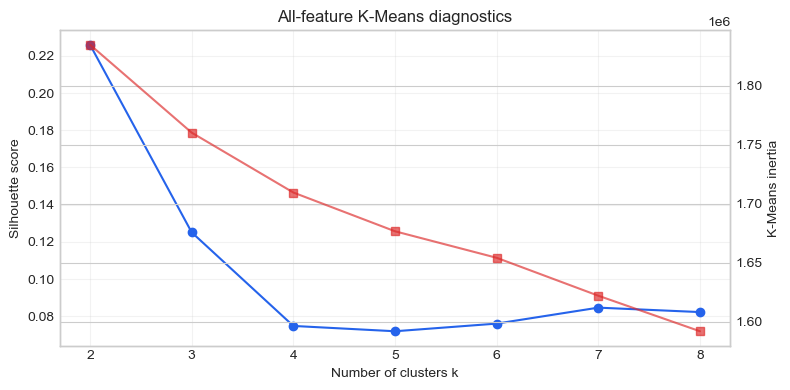

In [7]:
plot_k_diagnostics(all_scores, "All-feature K-Means diagnostics")


silhouette = are the clusters well-separated? \
inertia = how compact are the clusters?

In [8]:
all_k = int(all_scores.sort_values("silhouette", ascending=False).iloc[0]["k"])
all_model = fit_kmeans(X_all, all_k, random_state=CFG.random_state)
df_stage1[f"cluster_all_k{all_k}"] = all_model.labels_

cluster_overview(df_stage1, f"cluster_all_k{all_k}")


,cluster_all_k2,n_users,continuation_rate,dropout_rate,share_users
0,0,20296,0.591151,0.408849,0.90341
1,1,2170,0.762212,0.237788,0.09659


Higher early activity is associated with higher probability of coming back. \
Because `came_back` was excluded from the clustering features, this difference is not mechanically produced by the algorithm. \
It is a post-hoc association: users with stronger early engagement patterns are more likely to continue using Lernnavi.

In [9]:
top_z_features(df_stage1, f"cluster_all_k{all_k}", all_numeric_features, top_n=6)


,cluster,feature,z_difference,cluster_mean,global_mean
0,0,total_events_0_2,-0.241133,124.414121,185.233197
1,0,n_view_events_0_2,-0.237021,76.562130,111.302680
2,0,n_click_events_0_2,-0.234708,47.851991,73.930517
3,0,n_documents_0_2,-0.234497,18.468959,26.544734
4,0,total_transactions_0_2,-0.231063,25.831395,39.196742
5,0,n_sessions_0_2,-0.219050,2.827700,4.479347
6,1,total_events_0_2,2.255316,754.073733,185.233197
7,1,n_view_events_0_2,2.216854,436.230876,111.302680
8,1,n_click_events_0_2,2.195220,317.842857,73.930517
9,1,n_documents_0_2,2.193249,102.077419,26.544734


*This table shows for each cluster, which features are higher or lower than the global average (in standardized units).*

The strongest standardized differences between clusters are all activity-volume features. \
This indicates that K-Means primarily captures an engagement intensity axis rather than qualitatively different behavioral strategies.

Cluster 1 corresponds to highly active learners, with substantially above-average events, views, clicks, documents, transactions, and sessions during weeks 0-2. \
Cluster 0 is below the global average on the same dimensions and represents lower-engagement users.


## 5. Behavior-Only Learner Profiles

We remove profile and school variables, then cluster only early behavioral activity, performance, regularity, persistence, and breadth features.


In [10]:
X_behav, behav_preprocess = preprocess_features(df_stage1, behavior_features)
behav_scores = evaluate_kmeans(
    X_behav,
    range(CFG.k_min, CFG.k_max + 1),
    sample_size=CFG.silhouette_sample_size,
    random_state=CFG.random_state,
)
behav_scores


,k,silhouette,inertia
0,2,0.407662,398223.875109
1,3,0.169527,360385.242556
2,4,0.166007,327748.780523
3,5,0.185127,305163.971451
4,6,0.148046,286340.566974
5,7,0.150758,269749.743314
6,8,0.145426,256618.928311


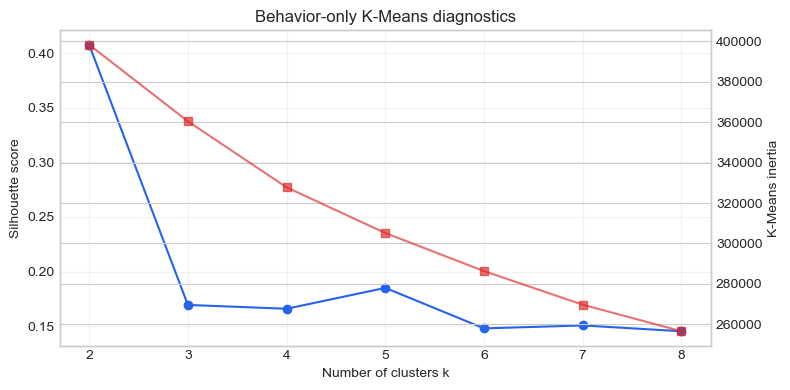

In [11]:
plot_k_diagnostics(behav_scores, "Behavior-only K-Means diagnostics")


Compared with the all-feature baseline, the behavior-only clustering gives a much stronger structure.

The best silhouette score increases from about 0.23 to about 0.41 for k=2, indicating that clusters are more compact and better separated when demographic and school-related variables are removed. 

This suggests that the main clustering signal comes from early learning behavior rather than from profile variables.

In [12]:
main_k = CFG.main_behavior_k
behav_k2 = fit_kmeans(X_behav, main_k, random_state=CFG.random_state)
df_stage1[f"cluster_behavior_k{main_k}"] = behav_k2.labels_

cluster_overview(df_stage1, f"cluster_behavior_k{main_k}")


,cluster_behavior_k2,n_users,continuation_rate,dropout_rate,share_users
0,0,20288,0.591483,0.408517,0.903054
1,1,2178,0.758494,0.241506,0.096946


In [13]:
important_features = [
    "total_events_0_2", "n_active_days_0_2", "n_click_events_0_2", "n_view_events_0_2",
    "n_sessions_0_2", "n_topics_event_0_2", "total_transactions_0_2", "correct_rate_0_2",
    "partial_rate_0_2", "mean_evaluation_score_0_2", "avg_response_time_0_2",
    "n_documents_0_2", "n_topics_transaction_0_2", "retry_ratio_0_2", "review_rate_0_2",
]
important_features = [c for c in important_features if c in df_stage1.columns]

profile_means_k2 = df_stage1.groupby(f"cluster_behavior_k{main_k}")[important_features + [LABEL_COL]].mean().round(3)
profile_means_k2


,total_events_0_2,n_active_days_0_2,n_click_events_0_2,n_view_events_0_2,n_sessions_0_2,n_topics_event_0_2,total_transactions_0_2,correct_rate_0_2,partial_rate_0_2,mean_evaluation_score_0_2,avg_response_time_0_2,n_documents_0_2,n_topics_transaction_0_2,retry_ratio_0_2,review_rate_0_2,came_back
cluster_behavior_k2,,,,,,,,,,,,,,,,
0,124.288,1.941,47.826,76.461,2.821,1.646,25.794,0.272,0.241,0.393,90.836,18.476,1.636,1.372,1.397,0.591
1,752.937,5.159,317.090,435.848,19.927,7.069,164.043,0.331,0.266,0.464,70.617,101.707,7.053,1.687,1.344,0.758


In [14]:
top_z_features(df_stage1, f"cluster_behavior_k{main_k}", behavior_features, top_n=10)


,cluster,feature,z_difference,cluster_mean,global_mean
0,0,total_events_0_2,-0.241634,124.287855,185.233197
1,0,n_view_events_0_2,-0.237708,76.461455,111.302680
2,0,n_click_events_0_2,-0.234938,47.826400,73.930517
3,0,n_documents_0_2,-0.234300,18.475749,26.544734
4,0,total_transactions_0_2,-0.231710,25.793967,39.196742
5,0,n_sessions_0_2,-0.219942,2.820978,4.479347
6,0,n_topics_transaction_0_2,-0.202096,1.636287,2.161444
7,0,n_topics_event_0_2,-0.201784,1.645554,2.171370
8,0,n_active_days_0_2,-0.169046,1.941246,2.253183
9,0,std_hour_0_2,-0.109905,1.212628,1.377908


The behavior-only k=2 clustering mainly separates users along an early engagement intensity axis.

Cluster 0 is slightly below the global average on all major activity features, with fewer events, views, clicks, documents, transactions, sessions, topics and active days. 

Cluster 1 is strongly above average on the same features.

This suggests that Cluster 1 corresponds to highly engaged early users, while Cluster 0 represents lower-engagement users.


## 6. Profile Dimensions

Compress related features into standardized dimensions


In [15]:
FEATURE_GROUPS = {
    "activity": [
        "total_events_0_2", "n_click_events_0_2", "n_view_events_0_2",
        "total_transactions_0_2", "n_documents_0_2",
    ],
    "regularity": [
        "n_active_days_0_2", "n_sessions_0_2", "time_between_sessions_mean_0_2",
        "mean_hour_0_2", "std_hour_0_2",
    ],
    "performance": [
        "correct_rate_0_2", "partial_rate_0_2", "mean_evaluation_score_0_2",
        "std_evaluation_score_0_2",
    ],
    "persistence": [
        "retry_ratio_0_2", "review_rate_0_2", "avg_response_time_0_2",
        "std_response_time_0_2", "session_duration_mean_0_2", "session_duration_std_0_2",
    ],
    "breadth": ["n_topics_event_0_2", "n_topics_transaction_0_2"],
}
FEATURE_GROUPS = {name: [c for c in cols if c in df_stage1.columns] for name, cols in FEATURE_GROUPS.items()}
FEATURE_GROUPS = {name: cols for name, cols in FEATURE_GROUPS.items() if cols}
FEATURE_GROUPS


{'activity': ['total_events_0_2',
  'n_click_events_0_2',
  'n_view_events_0_2',
  'total_transactions_0_2',
  'n_documents_0_2'],
 'regularity': ['n_active_days_0_2',
  'n_sessions_0_2',
  'time_between_sessions_mean_0_2',
  'mean_hour_0_2',
  'std_hour_0_2'],
 'performance': ['correct_rate_0_2',
  'partial_rate_0_2',
  'mean_evaluation_score_0_2',
  'std_evaluation_score_0_2'],
 'persistence': ['retry_ratio_0_2',
  'review_rate_0_2',
  'avg_response_time_0_2',
  'std_response_time_0_2',
  'session_duration_mean_0_2',
  'session_duration_std_0_2'],
 'breadth': ['n_topics_event_0_2', 'n_topics_transaction_0_2']}

In [16]:
def build_dimension_scores(df: pd.DataFrame, feature_groups: dict[str, list[str]]) -> pd.DataFrame:
    scores = pd.DataFrame(index=df.index)
    for group_name, cols in feature_groups.items():
        X_group, _ = preprocess_features(df, cols)
        scores[group_name] = X_group.mean(axis=1)
    return scores


def summarize_dimensions(scores: pd.DataFrame, df: pd.DataFrame, cluster_col: str, label_col: str) -> pd.DataFrame:
    joined = scores.copy()
    joined[cluster_col] = df[cluster_col].values
    joined[label_col] = df[label_col].values
    joined["user_id"] = df["user_id"].values
    return (
        joined.groupby(cluster_col)
        .agg(
            n_users=("user_id", "count"),
            continuation_rate=(label_col, "mean"),
            **{dim: (dim, "mean") for dim in scores.columns},
        )
        .round(3)
    )


def plot_dimension_profiles(summary: pd.DataFrame, title: str) -> None:
    dims = [c for c in summary.columns if c not in {"n_users", "continuation_rate"}]
    plot_df = summary[dims].T
    plot_df.columns = [f"C{idx} (n={int(summary.loc[idx, 'n_users'])})" for idx in summary.index]
    ax = plot_df.plot(kind="bar", figsize=(10, 4.5))
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Average standardized dimension score")
    ax.set_title(title)
    ax.legend(title="Cluster")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

dimension_scores = build_dimension_scores(df_stage1, FEATURE_GROUPS)
summary_k2 = summarize_dimensions(dimension_scores, df_stage1, f"cluster_behavior_k{main_k}", LABEL_COL)
summary_k2


,n_users,continuation_rate,activity,regularity,performance,persistence,breadth
cluster_behavior_k2,,,,,,,
0,20288,0.591,-0.236,-0.112,-0.026,-0.012,-0.202
1,2178,0.758,2.199,1.045,0.244,0.109,1.881


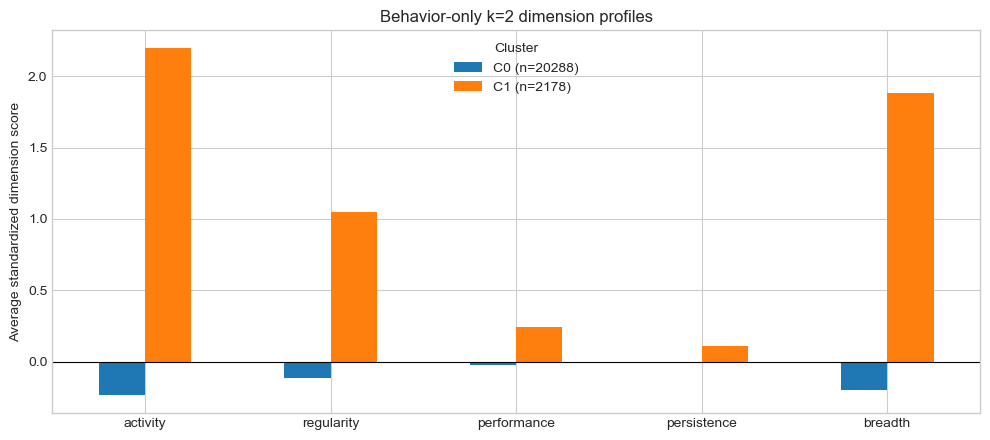

In [17]:
plot_dimension_profiles(summary_k2, f"Behavior-only k={main_k} dimension profiles")


The dimension profiles confirm that the behavior-only k=2 solution mainly captures early engagement intensity.

Cluster 1 is much higher on activity, regularity, and breadth

Cluster 0 is slightly below average on all dimensions. The difference in continuation rate is also substantial

Since the continuation label was not used during clustering, this suggests that early behavioral engagement is strongly associated with later retention.


## 7. Exploratory Five-Profile Solution

The two-cluster solution is usually the cleanest split, but `k=5` gives more subprofiles. We treat this as exploratory because its silhouette score is lower than the main solution.


In [18]:
exploratory_k = CFG.exploratory_behavior_k
behav_k5 = fit_kmeans(X_behav, exploratory_k, random_state=CFG.random_state)
df_stage1[f"cluster_behavior_k{exploratory_k}"] = behav_k5.labels_

cluster_overview(df_stage1, f"cluster_behavior_k{exploratory_k}")


,cluster_behavior_k5,n_users,continuation_rate,dropout_rate,share_users
0,0,12248,0.572093,0.427907,0.545179
1,1,497,0.796781,0.203219,0.022122
2,2,3874,0.707796,0.292204,0.172438
3,3,1454,0.734525,0.265475,0.064720
4,4,4393,0.555201,0.444799,0.195540


In [19]:
summary_k5 = summarize_dimensions(dimension_scores, df_stage1, f"cluster_behavior_k{exploratory_k}", LABEL_COL)
summary_k5


,n_users,continuation_rate,activity,regularity,performance,persistence,breadth
cluster_behavior_k5,,,,,,,
0,12248,0.572,-0.276,-0.211,0.313,-0.078,-0.288
1,497,0.797,4.477,1.770,0.293,0.063,3.324
2,3874,0.708,0.940,0.654,0.181,0.084,0.963
3,1454,0.735,-0.113,0.153,0.013,1.070,0.002
4,4393,0.555,-0.528,-0.240,-1.068,-0.219,-0.423


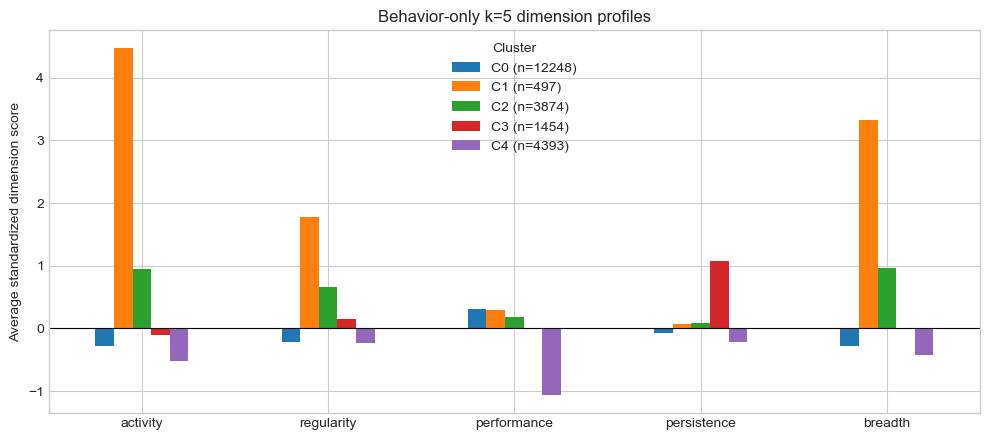

In [20]:
plot_dimension_profiles(summary_k5, f"Behavior-only k={exploratory_k} dimension profiles")


The k=5 behavior-only solution provides a more fine-grained view of early learner profiles.

While k=2 mainly separates low-engagement and high-engagement users, k=5 reveals several subgroups:
- a large low-activity but relatively successful group
- a small highly engaged group
- a moderately active regular group
- a persistence-oriented group
- a low-activity low-performance group

The continuation rates follow an interpretable pattern: the highly engaged and persistent groups have higher continuation rates, while the low-activity low-performance group has the highest dropout rate.


## 8. Robustness Checks

Compare the exploratory K-Means profiles with Gaussian Mixture Models and Agglomerative Clustering. Agglomerative clustering can be expensive, so it runs on a fixed random sample by default.


In [21]:
gmm = GaussianMixture(
    n_components=exploratory_k,
    covariance_type="full",
    random_state=CFG.random_state,
)
df_stage1[f"cluster_gmm_k{exploratory_k}"] = gmm.fit_predict(X_behav)

cluster_overview(df_stage1, f"cluster_gmm_k{exploratory_k}")


,cluster_gmm_k5,n_users,continuation_rate,dropout_rate,share_users
0,0,10807,0.566670,0.433330,0.481038
1,1,1128,0.746454,0.253546,0.050209
2,2,6283,0.670699,0.329301,0.279667
3,3,1737,0.656304,0.343696,0.077317
4,4,2511,0.530466,0.469534,0.111769


In [22]:
gmm_summary = summarize_dimensions(dimension_scores, df_stage1, f"cluster_gmm_k{exploratory_k}", LABEL_COL)
gmm_summary


,n_users,continuation_rate,activity,regularity,performance,persistence,breadth
cluster_gmm_k5,,,,,,,
0,10807,0.567,-0.297,-0.290,0.238,-0.117,-0.335
1,1128,0.746,2.446,1.047,0.034,0.172,1.646
2,6283,0.671,0.425,0.424,0.195,0.113,0.554
3,1737,0.656,-0.341,0.081,-0.355,0.812,-0.193
4,2511,0.530,-0.650,-0.341,-1.281,-0.420,-0.550


The GMM solution broadly confirms the K-Means profiles. 

It recovers a low-activity group, a highly engaged group, a moderately active group, a persistence-oriented group, and a low-activity low-performance group. The continuation rates follow the same pattern: more engaged profiles tend to have higher continuation, while the low-performance low-activity profile has the highest dropout rate.

In [23]:
sample_n = min(CFG.agglo_sample_size, len(df_stage1))
sample_idx = df_stage1.sample(sample_n, random_state=CFG.random_state).index

agglo = AgglomerativeClustering(n_clusters=exploratory_k, linkage="ward")
agglo_labels = agglo.fit_predict(X_behav[sample_idx])

agglo_df = df_stage1.loc[sample_idx].copy()
agglo_df[f"cluster_agglo_k{exploratory_k}"] = agglo_labels
agglo_scores = dimension_scores.loc[sample_idx]

cluster_overview(agglo_df, f"cluster_agglo_k{exploratory_k}")


,cluster_agglo_k5,n_users,continuation_rate,dropout_rate,share_users
0,0,3757,0.587969,0.412031,0.7514
1,1,477,0.727463,0.272537,0.0954
2,2,393,0.529262,0.470738,0.0786
3,3,65,0.846154,0.153846,0.0130
4,4,308,0.785714,0.214286,0.0616


In [24]:
agglo_summary = summarize_dimensions(agglo_scores, agglo_df, f"cluster_agglo_k{exploratory_k}", LABEL_COL)
agglo_summary


,n_users,continuation_rate,activity,regularity,performance,persistence,breadth
cluster_agglo_k5,,,,,,,
0,3757,0.588,-0.181,-0.099,0.158,-0.040,-0.159
1,477,0.727,-0.016,0.110,0.036,0.780,0.146
2,393,0.529,-0.651,-0.338,-1.764,-0.535,-0.536
3,65,0.846,5.627,1.977,0.356,0.051,2.594
4,308,0.786,1.877,1.013,0.238,0.075,1.937


Agglomerative clustering, applied on a sample for computational reasons, also recovers similar profiles. In particular, it identifies a low-performance low-activity group with the lowest continuation rate, a persistence-oriented group, and one or two highly engaged groups with the highest continuation rates. This supports the idea that the learner profiles are not specific to K-Means.


## 9. Trajectory Clustering

This section clusters 12-week behavior trajectories. It rebuilds weekly features through `preprocess.py`, so its long.\

Set `CFG.run_stage2 = True` in the configuration cell at the beginning


In [32]:
def build_sequences(
    df: pd.DataFrame,
    feature_cols: list[str],
    *,
    id_col: str,
    time_col: str,
    label_col: str,
    sequence_length: int,
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    df = df.sort_values([id_col, time_col]).dropna(subset=[label_col]).copy()
    df[label_col] = df[label_col].astype(int)

    X_weekly, _ = preprocess_features(df, feature_cols)
    y_all = df[label_col].to_numpy()
    users_all = df[id_col].to_numpy()
    weeks_all = df[time_col].to_numpy()
    index_all = df.index.to_numpy()

    X_sequences, y_sequences, metadata_rows = [], [], []
    for user_id, user_idx in df.groupby(id_col).indices.items():
        user_idx = np.asarray(user_idx)
        if len(user_idx) < sequence_length:
            continue
        for end_pos in range(sequence_length - 1, len(user_idx)):
            seq_positions = user_idx[end_pos - sequence_length + 1:end_pos + 1]
            end_position = user_idx[end_pos]
            X_sequences.append(X_weekly[seq_positions])
            y_sequences.append(int(y_all[end_position]))
            metadata_rows.append({
                id_col: user_id,
                "end_week": weeks_all[end_position],
                "row_index": index_all[end_position],
                label_col: int(y_all[end_position]),
            })

    return np.asarray(X_sequences), np.asarray(y_sequences), pd.DataFrame(metadata_rows)


def trajectory_dimension_curves(
    X_sequences: np.ndarray,
    feature_cols: list[str],
    feature_groups: dict[str, list[str]],
) -> dict[str, np.ndarray]:
    curves = {}
    for group_name, cols in feature_groups.items():
        indices = [feature_cols.index(c) for c in cols if c in feature_cols]
        if indices:
            curves[group_name] = X_sequences[:, :, indices].mean(axis=2)
    return curves


In [33]:
if CFG.run_stage2:
    import preprocess as preprocess_module

    users_clean, events_clean, transactions_clean, event_users_features, feature_cols, df_full = preprocess_module.preprocess(CFG.data_dir)

    stage2_df = df_full.copy()
    stage2_id_col = "user_id"
    stage2_time_col = "relative_week"
    stage2_label_col = "is_dropout_point"
    stage2_behavior_features = [c for c in feature_cols if c not in {"year", "day"}]

    X_seq, y_seq, traj_df = build_sequences(
        stage2_df,
        stage2_behavior_features,
        id_col=stage2_id_col,
        time_col=stage2_time_col,
        label_col=stage2_label_col,
        sequence_length=CFG.stage2_sequence_length,
    )

    print("Sequence tensor:", X_seq.shape)
    print("Interruption rate:", y_seq.mean().round(3))
else:
    print("Stage 2 skipped. Set CFG.run_stage2=True in the configuration cell to run trajectory clustering.")


Sequence tensor: (222739, 12, 15)
Interruption rate: 0.497


,k,silhouette,inertia
0,2,0.657762,2.616396e+07
1,3,0.485353,2.512033e+07
2,4,0.470957,2.429339e+07
3,5,0.480103,2.360451e+07
4,6,0.474242,2.302088e+07
5,7,0.455207,2.249101e+07
6,8,0.458005,2.199620e+07


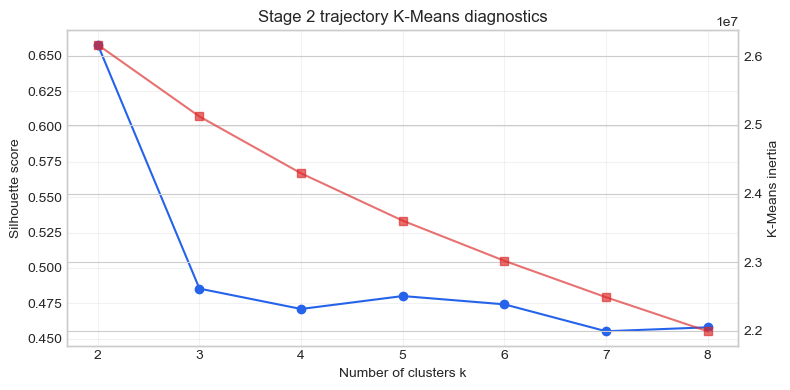

In [34]:
if CFG.run_stage2:
    n_samples, seq_len, n_features = X_seq.shape
    X_traj = X_seq.reshape(n_samples, seq_len * n_features)

    traj_scores = evaluate_kmeans(
        X_traj,
        range(CFG.k_min, CFG.k_max + 1),
        sample_size=CFG.silhouette_sample_size,
        random_state=CFG.random_state,
    )
    display(traj_scores)
    plot_k_diagnostics(traj_scores, "Stage 2 trajectory K-Means diagnostics")


In [35]:
if CFG.run_stage2:
    traj_model = fit_kmeans(X_traj, CFG.stage2_k, random_state=CFG.random_state)
    traj_df["trajectory_cluster"] = traj_model.labels_

    traj_overview = (
        traj_df.groupby("trajectory_cluster")
        .agg(
            n_sequences=(stage2_id_col, "count"),
            n_users=(stage2_id_col, "nunique"),
            interruption_rate=(stage2_label_col, "mean"),
        )
        .reset_index()
    )
    traj_overview["share_sequences"] = traj_overview["n_sequences"] / traj_overview["n_sequences"].sum()
    display(traj_overview)


,trajectory_cluster,n_sequences,n_users,interruption_rate,share_sequences
0,0,165019,7501,0.527951,0.740863
1,1,19377,7650,0.489601,0.086994
2,2,4098,1384,0.313568,0.018398
3,3,3996,688,0.234484,0.017940
4,4,30249,3696,0.392939,0.135805


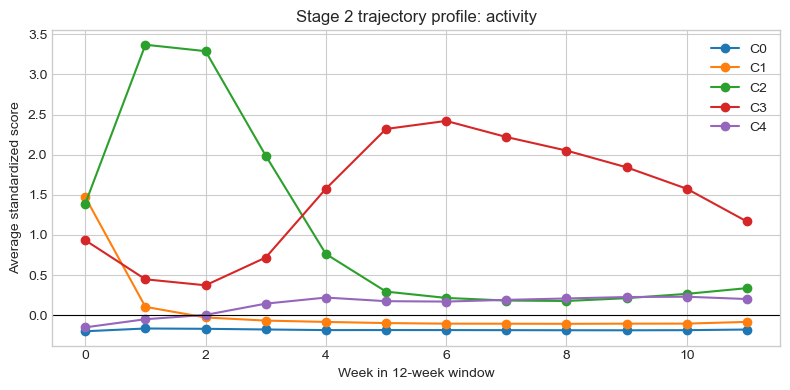

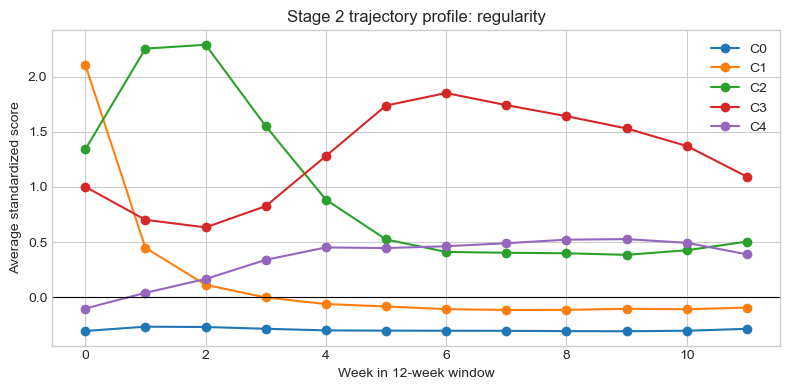

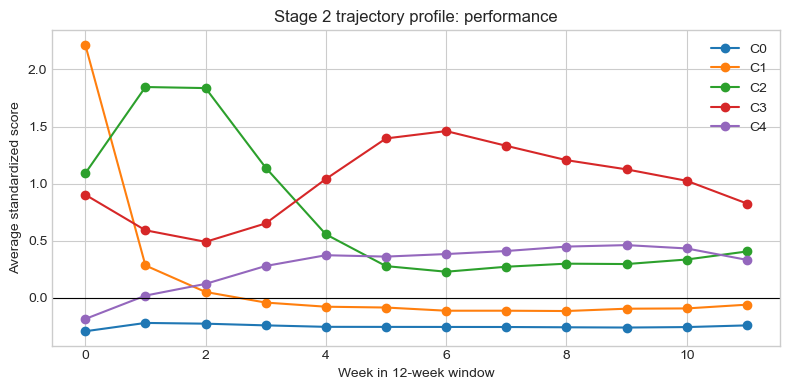

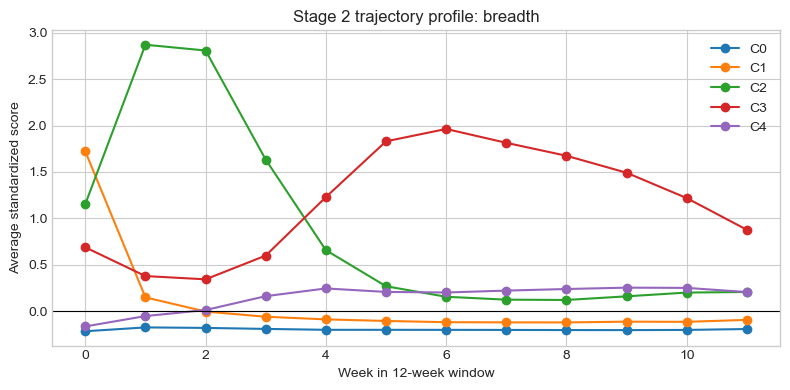

In [36]:
if CFG.run_stage2:
    trajectory_groups = {
        "activity": ["n_events", "n_click_events", "n_view_events", "n_transactions", "n_documents", "n_sessions", "activity_score"],
        "regularity": ["n_active_days", "mean_hour"],
        "performance": ["correct_rate", "partial_rate", "mean_evaluation_score"],
        "breadth": ["n_topics_event", "n_topics_transaction"],
    }
    dim_curves = trajectory_dimension_curves(X_seq, stage2_behavior_features, trajectory_groups)

    for dim, values in dim_curves.items():
        plt.figure(figsize=(8, 4))
        for cluster_id in sorted(traj_df["trajectory_cluster"].unique()):
            mask = traj_df["trajectory_cluster"].values == cluster_id
            plt.plot(values[mask].mean(axis=0), marker="o", label=f"C{cluster_id}")
        plt.axhline(0, color="black", linewidth=0.8)
        plt.title(f"Stage 2 trajectory profile: {dim}")
        plt.xlabel("Week in 12-week window")
        plt.ylabel("Average standardized score")
        plt.legend()
        plt.tight_layout()
        plt.show()


The Stage 2 trajectory clustering reveals temporal engagement patterns that cannot be observed from the Stage 1 aggregate features.

- The largest cluster, C0, corresponds to consistently low trajectories and has the highest interruption rate.
- C1 captures users who start with high activity and performance but drop rapidly after the first week.
- C2 also shows an early peak followed by decline, but with lower interruption risk.
- C3 is the most favorable profile: users increase their engagement after the first weeks and maintain high activity, regularity, performance and breadth, resulting in the lowest interruption rate.
- C4 represents stable moderate trajectories with intermediate interruption risk.


Compared with Stage 1 clustering, Stage 2 provides a dynamic view of learner behavior. Stage 1 mainly separates users by early engagement level, while Stage 2 distinguishes how engagement evolves over time: consistently low, rapidly declining, early-peaking, delayed sustained engagement, and stable moderate trajectories.


The lowest interruption rate is observed for trajectories with sustained or increasing engagement, while the highest interruption rates are associated with consistently low or rapidly declining trajectories.

## 10. Save Cluster Assignments

Only cluster labels and IDs are exported. The label columns are included to make downstream interpretation easy, but remember they were not used for fitting.


In [37]:
if CFG.save_outputs:
    cluster_cols = [c for c in df_stage1.columns if c.startswith("cluster_")]
    stage1_assignments = df_stage1[[ID_COL, LABEL_COL] + cluster_cols].copy()
    output_path = CFG.output_dir / "stage1_cluster_assignments.csv"
    stage1_assignments.to_csv(output_path, index=False)
    print(f"Saved {output_path} with shape {stage1_assignments.shape}")
else:
    print("Output saving disabled.")


Saved outputs\stage1_cluster_assignments.csv with shape (22466, 6)
